In [1]:
import pandas as pd

df = pd.read_csv("Fraud.csv")

In [2]:
print(f"Total Rows Are : {df.shape[0]} and Total Columns Are: {df.shape[1]}.\n")
print(f"Total Duplicated Values are : {df.duplicated().sum()}\n")

print(f"Null Values are:\n{df.isnull().sum()}")

Total Rows Are : 6362620 and Total Columns Are: 11.

Total Duplicated Values are : 0

Null Values are:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
print("Lets see 10 Random rows of Dataset")
print(df.sample(10))

Lets see 10 Random rows of Dataset
         step      type      amount     nameOrig  oldbalanceOrg  \
2815919   225  CASH_OUT   417100.30  C1520392551           0.00   
2817379   225  CASH_OUT   635297.06  C1023744495       64298.34   
416249     18  CASH_OUT   156100.92   C510515973           0.00   
2194805   185  CASH_OUT    76558.47  C1304123451        6209.00   
4713132   332   PAYMENT     4908.00   C689266442           0.00   
5098528   355  CASH_OUT    68916.76   C195299261           0.00   
39987       9  TRANSFER  1601765.30    C81140578        1312.00   
2817606   225  TRANSFER   983918.99  C2129466041           0.00   
4180078   304   CASH_IN   311880.04  C2126516915      497315.19   
956912     44   CASH_IN    99747.48   C430466440         834.00   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
2815919            0.00   C373496977       993646.84      1410747.14        0   
2817379            0.00  C1332137113       965217.86      1600514

In [5]:
#transaction type
print(df['type'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [8]:
# fraud vs normal
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [9]:
print(df['isFlaggedFraud'].value_counts())

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [10]:
df.columns = df.columns.str.strip()
print(df.describe())

               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%      0.000000e+00    0.000000e+00

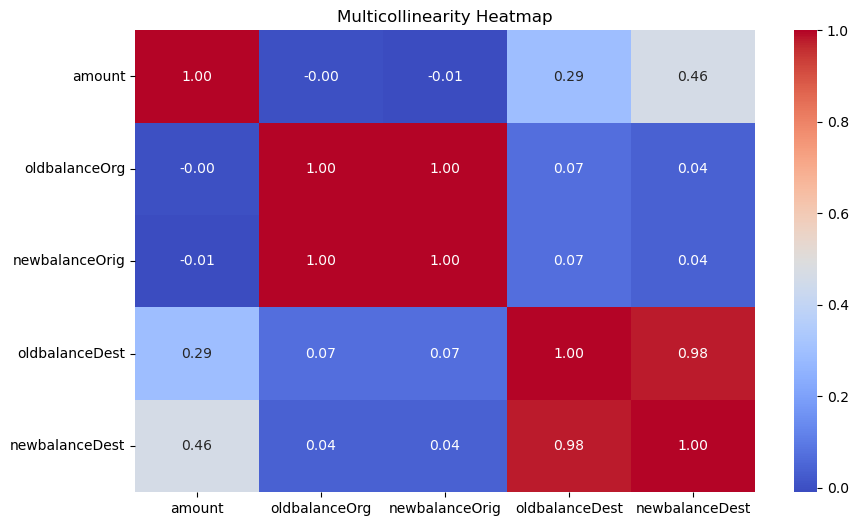

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
correlation_matrix = df[num_cols].corr().round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Multicollinearity Heatmap")
plt.show()

In [13]:
# before scaling
df['sender_balance_error'] = df['newbalanceOrig'] - df['oldbalanceOrg'] + df['amount']
df['receiver_balance_error'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

print(df[['sender_balance_error', 'receiver_balance_error']].head())

   sender_balance_error  receiver_balance_error
0         -1.455192e-11                -9839.64
1          1.136868e-12                -1864.28
2          0.000000e+00                 -181.00
3          0.000000e+00               -21363.00
4          0.000000e+00               -11668.14


In [14]:
# replaced by error features
df = df.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'])

In [15]:
# scale after feature engineering
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
columns_to_scale = ['amount', 'sender_balance_error', 'receiver_balance_error']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print(df[columns_to_scale].describe())

             amount  sender_balance_error  receiver_balance_error
count  6.362620e+06          6.362620e+06            6.362620e+06
mean   5.374952e-01          5.367745e-01           -1.773809e+00
std    3.091447e+00          2.459192e+00            1.504201e+01
min   -3.833062e-01         -2.783986e-01           -4.492799e+02
25%   -3.147585e-01         -2.664229e-01           -8.807453e-01
50%    0.000000e+00         -2.949471e-17            0.000000e+00
75%    6.852415e-01          7.335771e-01            1.192547e-01
max    4.728907e+02          3.744700e+02            2.585395e+03


In [16]:
print(df['type'].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [17]:
# fraud only in these two
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print("Shape after filtering:", df_model.shape)
print("Fraud cases kept:", df_model['isFraud'].sum())

Shape after filtering: (2770409, 9)
Fraud cases kept: 8213


In [18]:
# useless columns
df_model = df_model.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

df_model = pd.get_dummies(df_model, columns=['type'], drop_first=False, dtype=int)

print("Final columns we have:")
print(df_model.columns.tolist())
print("Final shape:")
print(df_model.shape)

Final columns we have:
['step', 'amount', 'isFraud', 'sender_balance_error', 'receiver_balance_error', 'type_CASH_OUT', 'type_TRANSFER']
Final shape:
(2770409, 7)


In [19]:
print("Final columns we have:")
print(df.columns.tolist())

print("Final shape:")
print(df.shape)

Final columns we have:
['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud', 'sender_balance_error', 'receiver_balance_error']
Final shape:
(6362620, 9)


In [20]:
df.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,sender_balance_error,receiver_balance_error
0,1,PAYMENT,-0.332932,C1231006815,M1979787155,0,0,-0.278399,-0.215962
1,1,PAYMENT,-0.373762,C1666544295,M2044282225,0,0,-0.278399,0.055742
2,1,TRANSFER,-0.382380,C1305486145,C553264065,1,0,-0.278399,0.113088
3,1,CASH_OUT,-0.382380,C840083671,C38997010,1,0,-0.278399,-0.608540
4,1,PAYMENT,-0.323571,C2048537720,M1230701703,0,0,-0.278399,-0.278256


In [21]:
# selecting features
features = ['step', 'amount', 'type_TRANSFER', 'type_CASH_OUT',
            'sender_balance_error', 'receiver_balance_error']

X = df_model[features]
y = df_model['isFraud']

print("Features we are using:")
print(X.columns.tolist())

print("\nFraud breakdown:")
print(y.value_counts())

Features we are using:
['step', 'amount', 'type_TRANSFER', 'type_CASH_OUT', 'sender_balance_error', 'receiver_balance_error']

Fraud breakdown:
isFraud
0    2762196
1       8213
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

# 70/30 split, fraud ratio preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Fraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training size: (1939286, 6)
Testing size: (831123, 6)
Fraud in training: 5749
Fraud in testing: 2464


In [23]:
fraud_count = y_train.sum()
normal_count = len(y_train) - fraud_count
scale = normal_count / fraud_count

print(f"Normal transactions: {normal_count}")
print(f"Fraud transactions: {fraud_count}")
print(f"scale_pos_weight: {scale:.2f}")

Normal transactions: 1933537
Fraud transactions: 5749
scale_pos_weight: 336.33


In [24]:
# XGBoost works well with imbalanced data
import xgboost as xgb


model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model training done!")

Model training done!


In [25]:
# 0/1 predictions and probability scores
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions done!")
print("Sample predictions:", y_pred[:10])

Predictions done!
Sample predictions: [0 0 0 0 0 0 0 0 0 0]


In [26]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    828659
           1       0.15      0.93      0.26      2464

    accuracy                           0.98    831123
   macro avg       0.57      0.96      0.62    831123
weighted avg       1.00      0.98      0.99    831123



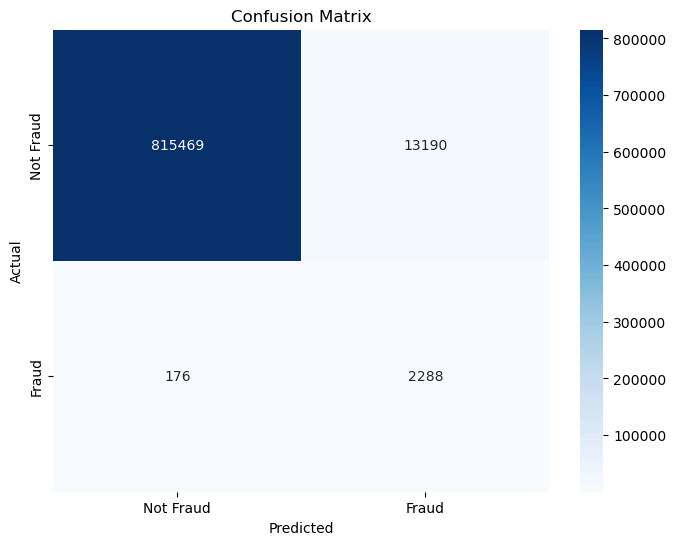

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# actual vs predicted
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9946


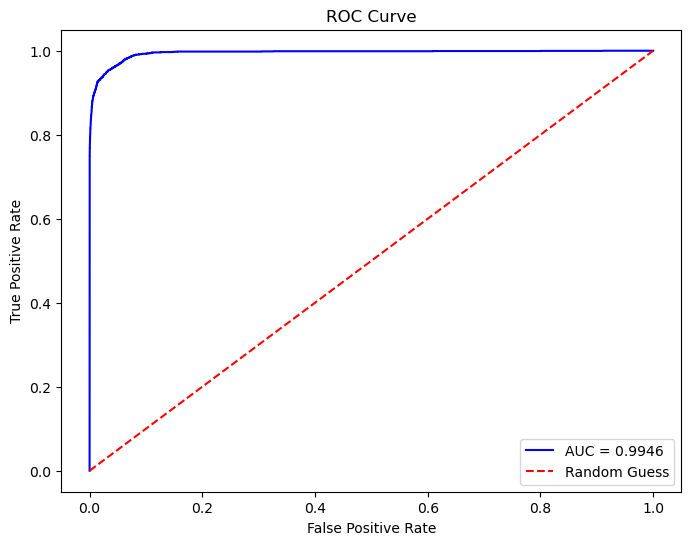

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [30]:
feature_names = X_train.columns.tolist()
importance_scores = model.feature_importances_

fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending=False)

print(fi)

                  Feature  Importance
4    sender_balance_error    0.919190
5  receiver_balance_error    0.027406
2           type_TRANSFER    0.018984
1                  amount    0.017869
0                    step    0.016552
3           type_CASH_OUT    0.000000


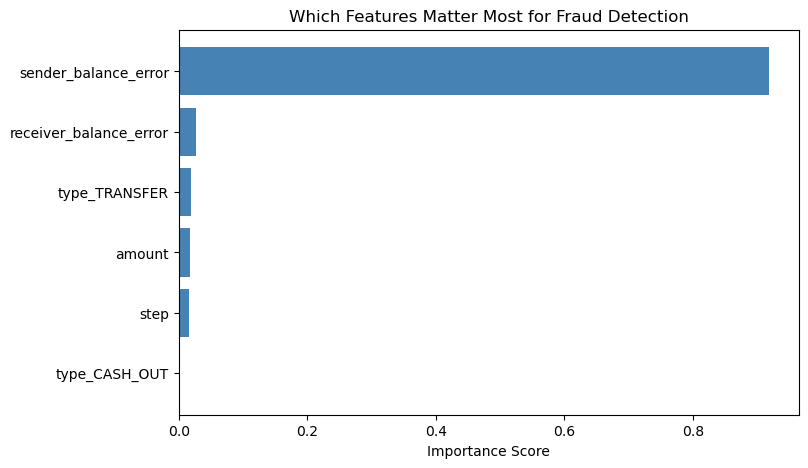

In [31]:
plt.figure(figsize=(8, 5))
plt.barh(fi['Feature'], fi['Importance'], color='steelblue')
plt.title("Which Features Matter Most for Fraud Detection")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()